### SHAP EXPLAINABILITY ANALYSIS — XGBoost

In [1]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# --- Load saved model and data ---
xgb_best = joblib.load('../models/xgboost.pkl')
df = pd.read_csv('../data/cardio_clean.csv')

X = df.drop(['cardio', 'bmi_category', 'age_category'], axis=1)
y = df['cardio']

In [2]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Same split settings as before, but NO scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain XGBoost on unscaled data using the same tuned hyperparameters
xgb_unscaled = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_unscaled.fit(X_train, y_train)

print("Unscaled XGBoost trained — confirming performance matches original:")
from sklearn.metrics import roc_auc_score
prob = xgb_unscaled.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, prob):.4f}")

Unscaled XGBoost trained — confirming performance matches original:
ROC-AUC: 0.7982


In [3]:
# --- SHAP TreeExplainer ---
explainer = shap.TreeExplainer(xgb_unscaled)

# Use a representative sample, not a token subset
# 2000+ rows gives a smooth, non-banded plot without being slow
sample_size = 2000
X_sample = X_test.sample(n=sample_size, random_state=42)

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {sample_size} patients")
print(f"Shape: {shap_values.shape}")

SHAP values computed for 2000 patients
Shape: (2000, 12)


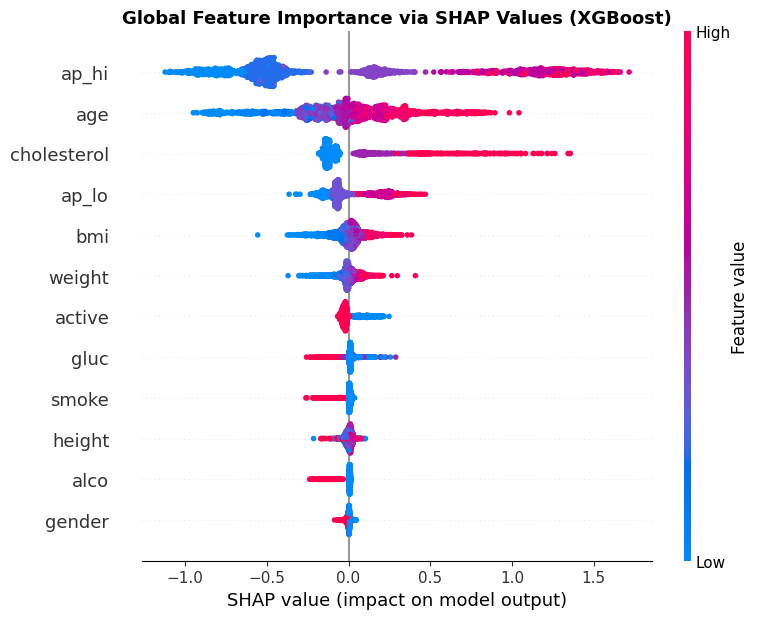

Saved to outputs/shap_beeswarm.png


In [4]:
# --- Global Feature Importance — Beeswarm ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)
plt.title('Global Feature Importance via SHAP Values (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/shap_beeswarm.png")

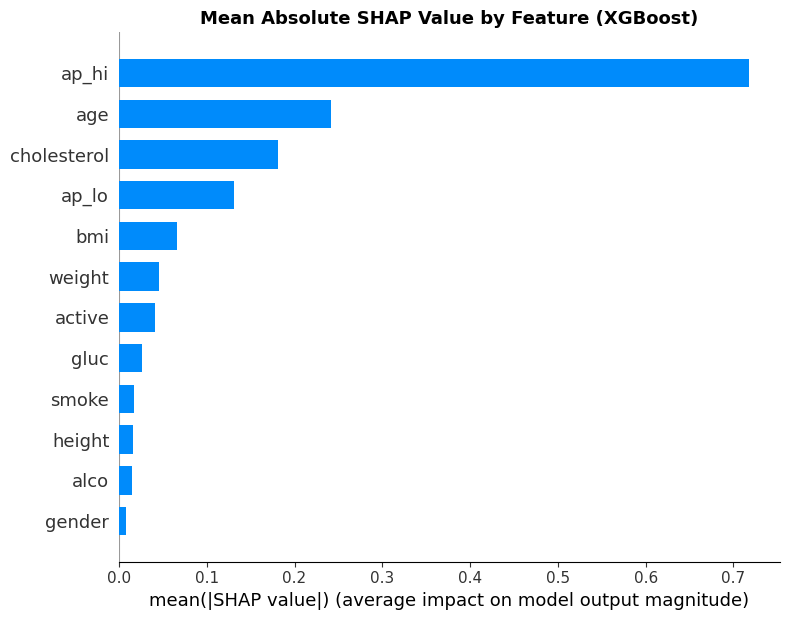

In [5]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)
plt.title('Mean Absolute SHAP Value by Feature (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

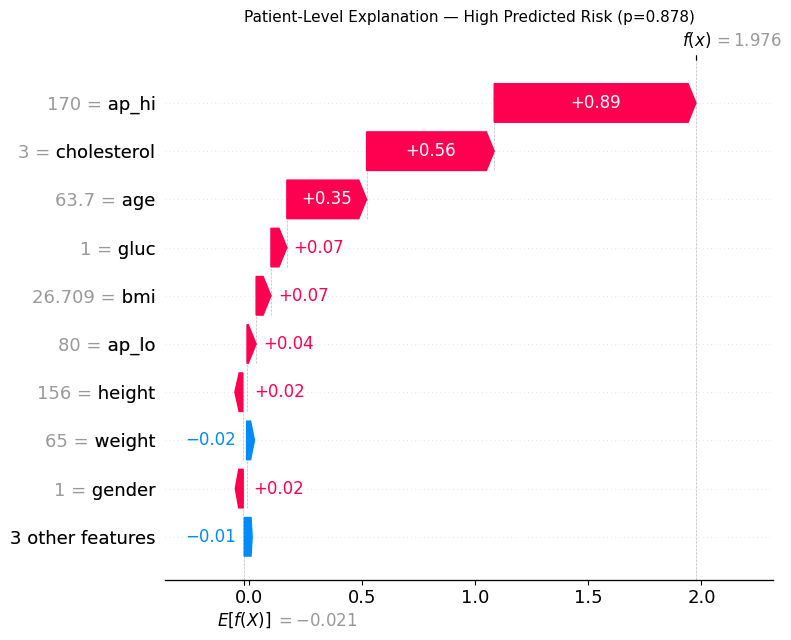

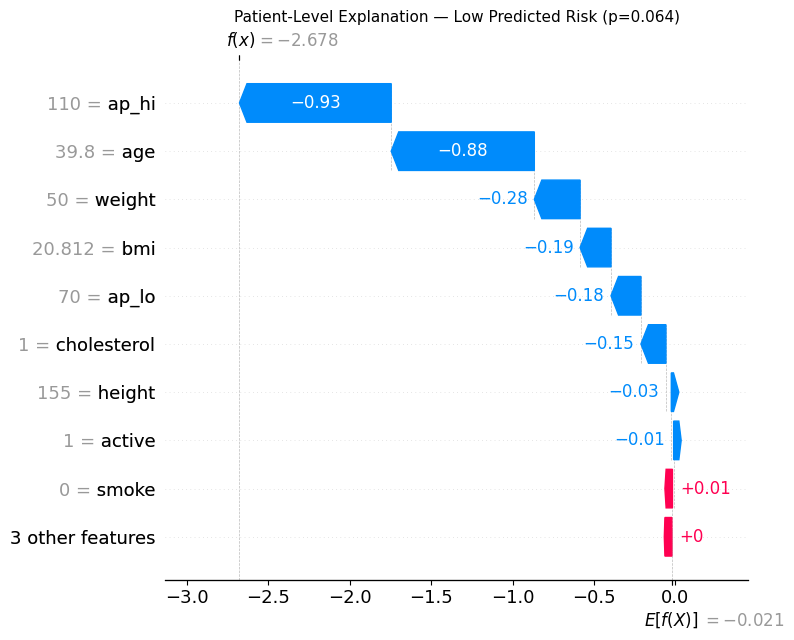

In [6]:
# --- Individual Patient Explanation (Waterfall) ---
# Pick one patient predicted high risk and one low risk
sample_pred_probs = xgb_unscaled.predict_proba(X_sample)[:, 1]
high_risk_idx = sample_pred_probs.argmax()
low_risk_idx = sample_pred_probs.argmin()

# High risk patient
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[high_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f'Patient-Level Explanation — High Predicted Risk (p={sample_pred_probs[high_risk_idx]:.3f})', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Low risk patient
plt.figure(figsize=(10, 6))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[low_risk_idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f'Patient-Level Explanation — Low Predicted Risk (p={sample_pred_probs[low_risk_idx]:.3f})', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()